In [10]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob

#### Load all the images from the dataset


In [11]:
def load_image(path):
    img = np.array(Image.open(path).convert('L'))
    return img

def save_image(array, path):
    Image.fromarray(array.astype(np.uint8)).save(path)

#Create output folder
for folder in ["output/enhancement", "output/filtering", "output/edge_detection"]:
    os.makedirs(folder, exist_ok=True)

#Load images from input folder
image_path =glob.glob("Data/**/*.jpg", recursive=True) + glob.glob("Data/**/*.png", recursive=True)

print(f"Found {len(image_path)} images in the input folder.")

Found 84 images in the input folder.


#### Image Enhancement

In [12]:
def compute_histogram(image):
    """Count frequency of each pixel value (0-255)"""
    hist = np.zeros(256, dtype=int)
    for val in image.flatten():
        hist[val] += 1
    return hist

def histogram_equalization(image):
    """Spread pixel values evenly across 0-255"""
    hist = compute_histogram(image)
    
    # Running total of histogram
    cdf = np.cumsum(hist)
    
    # Normalize to 0-255 range
    h, w = image.shape
    cdf_min = cdf[cdf > 0].min()
    
    # Build lookup table — maps old pixel value to new one
    lut = np.round(
        (cdf - cdf_min) / ((h * w) - cdf_min) * 255
    ).astype(np.uint8)
    
    # Apply lookup table to every pixel
    return lut[image]

In [13]:
def gamma_correction(image, gamma=1.5):
    """
    gamma < 1 → brightens dark images
    gamma > 1 → darkens bright/washed-out images
    """
    # Normalize to 0-1, apply gamma, scale back to 0-255
    normalized = image / 255.0
    corrected = np.power(normalized, 1.0 / gamma)
    return (corrected * 255).astype(np.uint8)

#### Displaying and saving enhancemnet results

In [ ]:
def show_enhancement(original, enhanced, title, save_path):
    """Show original vs enhanced with histograms"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Original image
    axes[0,0].imshow(original, cmap='gray')
    axes[0,0].set_title("Original")
    axes[0,0].axis('off')
    
    # Enhanced image
    axes[0,1].imshow(enhanced, cmap='gray')
    axes[0,1].set_title(f"Enhanced ({title})")
    axes[0,1].axis('off')
    
    # Original histogram
    axes[1,0].bar(range(256), compute_histogram(original), color='blue', alpha=0.7)
    axes[1,0].set_title("Histogram - Original")
    axes[1,0].set_xlabel("Pixel Value")
    axes[1,0].set_ylabel("Count")
    
    # Enhanced histogram
    axes[1,1].bar(range(256), compute_histogram(enhanced), color='green', alpha=0.7)
    axes[1,1].set_title("Histogram - Enhanced")
    axes[1,1].set_xlabel("Pixel Value")
    axes[1,1].set_ylabel("Count")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# Apply to your images
for i, path in enumerate(image_path[:4]):   # at least 4 examples
    img = load_image(path)
    name = os.path.basename(path)
    
    # Histogram Equalization
    eq = histogram_equalization(img)
    show_enhancement(img, eq, "Histogram Equalization",
                     f"output/enhancement/histeq_{name}.png")
    save_image(eq, f"output/enhancement/histeq_{name}")
    
    # Gamma Correction
    gc = gamma_correction(img, gamma=1.5)
    show_enhancement(img, gc, "Gamma Correction",
                     f"output/enhancement/gamma_{name}.png")
    save_image(gc, f"output/enhancement/gamma_{name}")

#### Image Filtering

In [17]:
def gaussian_kernel(size=5, sigma=1.0):
    """Build a Gaussian blur kernel from scratch"""
    k = size // 2
    x, y = np.mgrid[-k:k+1, -k:k+1]
    kernel = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return kernel / kernel.sum()

def convolve2d(image, kernel):
    """Slide kernel across image and compute weighted average"""
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    
    # Pad edges so border pixels get processed too
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='reflect')
    
    output = np.zeros_like(image, dtype=np.float64)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    
    return np.clip(output, 0, 255).astype(np.uint8)

def gaussian_filter(image, size=5, sigma=1.0):
    kernel = gaussian_kernel(size, sigma)
    return convolve2d(image, kernel)

In [18]:
# meidan filter
def median_filter(image, size=3):
    pad = size // 2
    padded = np.pad(image, pad, mode='reflect')
    output = np.zeros_like(image)
    
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+size, j:j+size]
            output[i, j] = np.median(region)
    
    return output.astype(np.uint8)

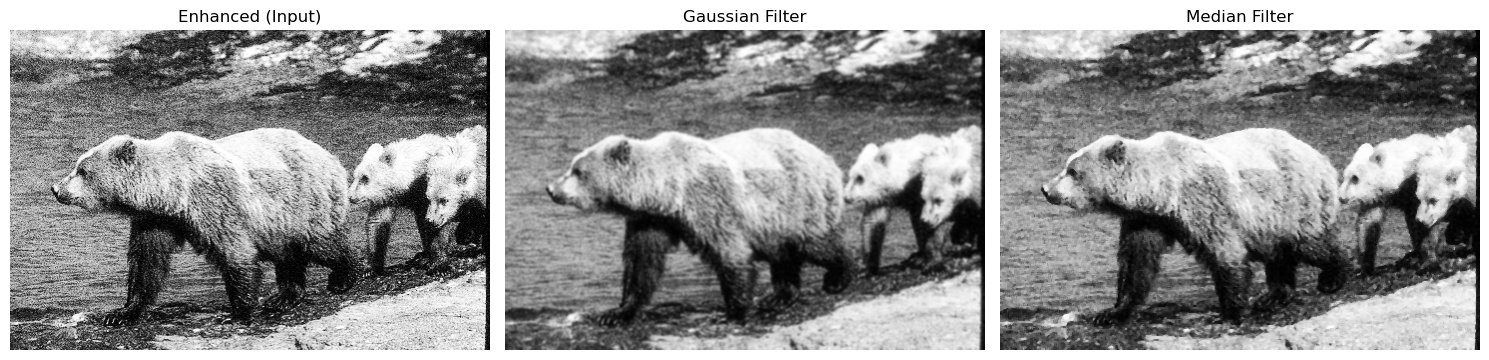

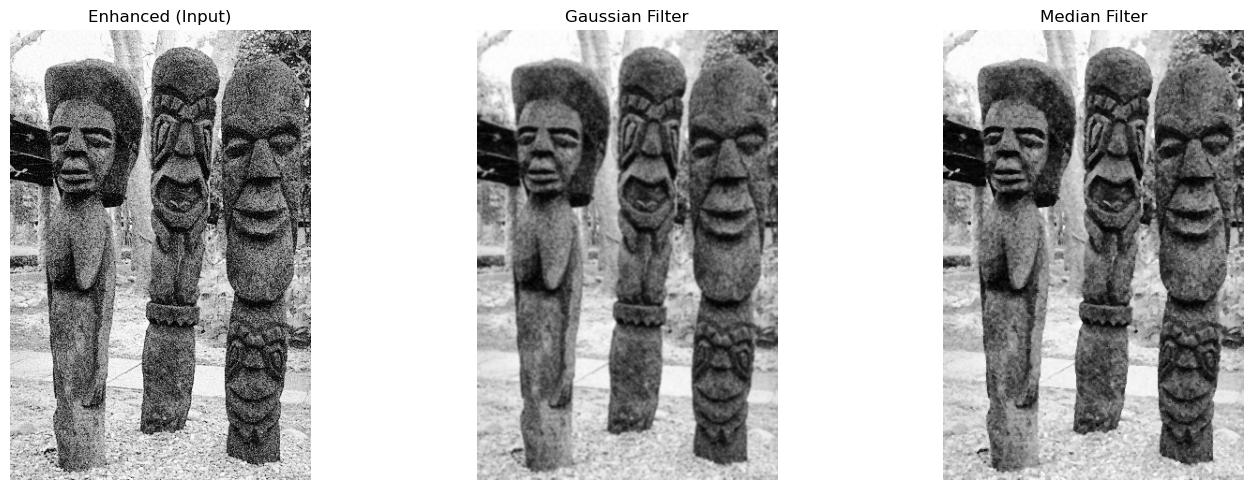

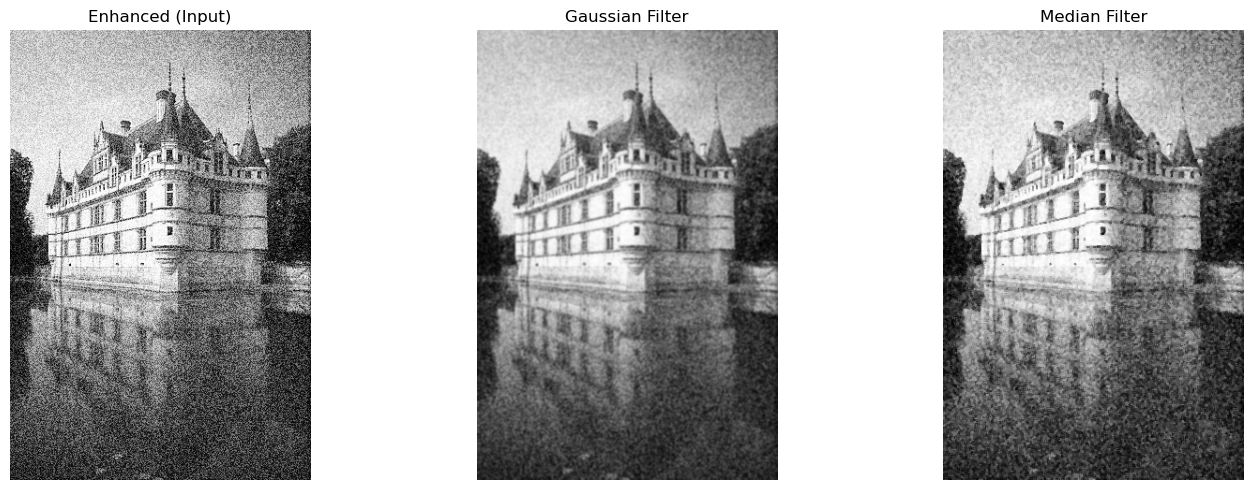

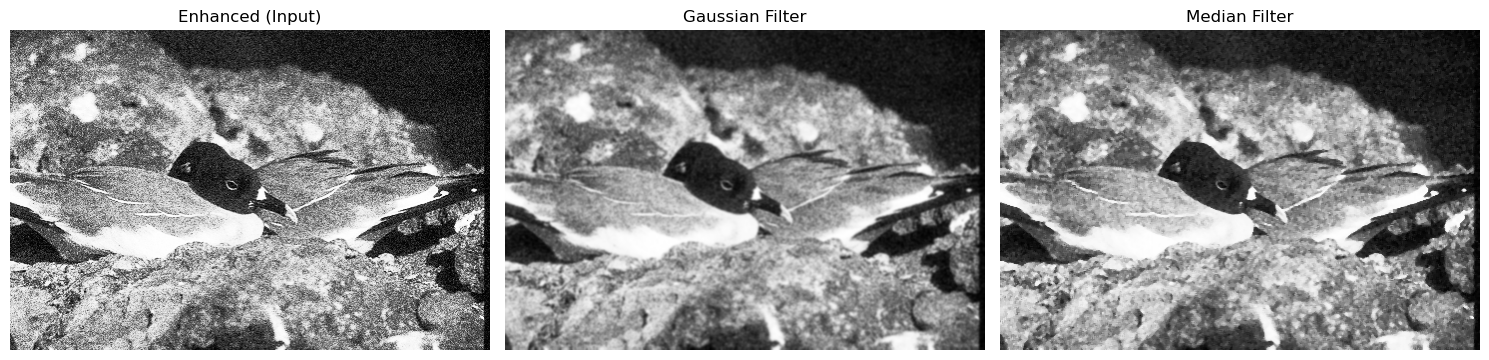

In [20]:
#Diplay original, Gaussian, and Median filtered images side by side
def show_filtering(original, gaussian, median, save_path):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Enhanced (Input)")
    axes[0].axis('off')
    
    axes[1].imshow(gaussian, cmap='gray')
    axes[1].set_title("Gaussian Filter")
    axes[1].axis('off')
    
    axes[2].imshow(median, cmap='gray')
    axes[2].set_title("Median Filter")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()

# Apply to enhanced images
for i, path in enumerate(image_path[:4]):
    img = load_image(path)
    enhanced = histogram_equalization(img)
    name = os.path.basename(path)
    
    g = gaussian_filter(enhanced)
    m = median_filter(enhanced)
    
    show_filtering(enhanced, g, m,
                   f"output/filtering/filter_{name}.png")
    save_image(g, f"output/filtering/gaussian_{name}")
    save_image(m, f"output/filtering/median_{name}")